<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# **Procesamiento de Lenguaje Natural**
## **Desafio, Traductor**

### **Consigna**

* Replicar el modelo traductor desarrollado en clase (https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/blob/may_2026/Clase%206/C%C3%B3digo/Traductor.ipynb) y extender su entrenamiento utilizando un conjunto de datos más amplio y secuencias de mayor longitud.
* Modificar valores de hiperparámetros (por ejemplo, el número de unidades en las capas LSTM) y analizar su impacto en el desempeño del traductor.
* Analizar el impacto del número de neuronas en las capas recurrentes, comparando el desempeño de distintas configuraciones del modelo.
* Generar y presentar al menos cinco ejemplos de traducciones producidas por el modelo entrenado.
* Interpretar a detalle los resultados obtenidos, considerando métricas de evaluación, calidad de las traducciones y posibles limitaciones del enfoque utilizado.

### **Actividades opcionales**

* Incorporar embeddings preentrenados para ambos idiomas y evaluar su efecto sobre el rendimiento del modelo.
* Experimentar con diferentes estrategias de generación de secuencias, como muestreo aleatorio (sampling) o búsqueda por haz (beam search).
* Implementar y entrenar una versión equivalente del modelo utilizando PyTorch, comparando los resultados con la implementación original.

Importamos las librerías necesarias para el script. En este caso, utilizamos la biblioteca `os` para interactuar con el sistema operativo y la biblioteca `sys` para acceder a los argumentos de línea de comandos. Además, importamos `argparse` para manejar los argumentos de manera más estructurada y `logging` para registrar eventos y errores durante la ejecución del script.

In [42]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding, Dropout
from tensorflow.keras.models import Model
import pickle
import os

Descargamos el dataset de traducción de Español-Inglés

In [43]:

import urllib.request
import zipfile

if not os.path.exists('spa-eng'):
    if not os.path.exists('spa-eng.zip'):
        print("Descargando dataset spa-eng...")
        urllib.request.urlretrieve(
            'http://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip',
            'spa-eng.zip'
        )
    print("Extrayendo...")
    with zipfile.ZipFile('spa-eng.zip', 'r') as z:
        z.extractall('.')
    print("Dataset listo.")
else:
    print("Dataset ya disponible.")

with open("./spa-eng/spa.txt", encoding='utf-8') as f:
    lines = f.read().split("\n")[:-1]

print(f"Total de líneas: {len(lines)}")

Dataset ya disponible.
Total de líneas: 118964


Definimos el número máximo de oraciones y la semilla

In [44]:
MAX_NUM_SENTENCES = 10000

np.random.seed(40)
np.random.shuffle(lines)

Cargamos los datos

In [45]:
input_sentences, output_sentences, output_sentences_inputs = [], [], []

for i, line in enumerate(lines):
    if i >= MAX_NUM_SENTENCES:
        break
    if '\t' not in line:
        continue
    input_sentence, output = line.rstrip().split('\t')[:2]
    output_sentences.append(output + ' <eos>')
    output_sentences_inputs.append('<sos> ' + output)
    input_sentences.append(input_sentence)

print(f"Oraciones cargadas: {len(input_sentences)}")

Oraciones cargadas: 10000


In [46]:
print(input_sentences[0])
print(output_sentences[0])
print(output_sentences_inputs[0])

Somebody stole my car.
Alguien robó mi auto. <eos>
<sos> Alguien robó mi auto.


Aplicamos tokenización

In [47]:
MAX_VOCAB_SIZE = 8000

input_tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE)
input_tokenizer.fit_on_texts(input_sentences)
input_integer_seq = input_tokenizer.texts_to_sequences(input_sentences)
word2idx_inputs = input_tokenizer.word_index

#Solo se tomarán en cuenta las 8000 palabras más frecuentes y se eliminan signos de puntuación
output_tokenizer = Tokenizer(
    num_words=MAX_VOCAB_SIZE,
    filters='!"#$%&()*+,-./:;=¿?@[\\]^_`{|}~\t\n'
)

output_tokenizer.fit_on_texts(["<sos>", "<eos>"] + output_sentences)
output_integer_seq = output_tokenizer.texts_to_sequences(output_sentences)
output_input_integer_seq = output_tokenizer.texts_to_sequences(output_sentences_inputs)
word2idx_outputs = output_tokenizer.word_index

num_words_output = min(len(word2idx_outputs) + 1, MAX_VOCAB_SIZE)

max_input_len = 20
max_out_len   = 22

print(f"Vocabulario EN: {len(word2idx_inputs)} | ES: {len(word2idx_outputs)}")
print(f"max_input_len={max_input_len}  max_out_len={max_out_len}")

Vocabulario EN: 4977 | ES: 7803
max_input_len=20  max_out_len=22


Aplicamos padding a las secuencias

In [48]:
encoder_input_sequences  = pad_sequences(input_integer_seq,        maxlen=max_input_len)
decoder_input_sequences  = pad_sequences(output_input_integer_seq, maxlen=max_out_len, padding='post')
decoder_output_sequences = pad_sequences(output_integer_seq,       maxlen=max_out_len, padding='post')

In [49]:
print(encoder_input_sequences[0])
print(decoder_input_sequences[0])
print(decoder_output_sequences[0])

[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 702 752
  16 104]
[3434  157  613   21  246    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0]
[157 613  21 246   1   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0]


Definimos función para obtener un tf.data.Dataset.

Esta función construye un tf.data.Dataset que genera batches de (encoder_in, decoder_in) a one-hot targets.

In [50]:
def make_dataset(enc_seqs, dec_in_seqs, dec_out_seqs, batch_size, num_classes):

    n = len(enc_seqs)

    def generator():
        for i in range(n):
            yield (
                enc_seqs[i].astype(np.int32),
                dec_in_seqs[i].astype(np.int32),
                dec_out_seqs[i].astype(np.int32),
            )

    def encode_one_hot(enc, dec_in, dec_out):
        y = tf.one_hot(dec_out, depth=num_classes)          # shape (max_out_len, num_classes)
        return (enc, dec_in), y

    ds = tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            tf.TensorSpec(shape=(max_input_len,), dtype=tf.int32),
            tf.TensorSpec(shape=(max_out_len,),   dtype=tf.int32),
            tf.TensorSpec(shape=(max_out_len,),   dtype=tf.int32),
        )
    )
    ds = ds.map(encode_one_hot, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

Aplicamos la función en el dataset para obtener el train y validation set

In [51]:
BATCH_SIZE = 64
val_split  = 0.15
split_idx  = int(len(encoder_input_sequences) * (1 - val_split))

train_ds = make_dataset(
    encoder_input_sequences[:split_idx],
    decoder_input_sequences[:split_idx],
    decoder_output_sequences[:split_idx],
    BATCH_SIZE, num_words_output
)
val_ds = make_dataset(
    encoder_input_sequences[split_idx:],
    decoder_input_sequences[split_idx:],
    decoder_output_sequences[split_idx:],
    BATCH_SIZE, num_words_output
)

Definimos función para descargar los embeddings de GloVe

In [52]:
import subprocess, sys, requests

def _is_valid_pickle(path):
    try:
        with open(path, 'rb') as f:
            head = f.read(20)
        return b'<html' not in head.lower() and b'<!doctype' not in head.lower()
    except Exception:
        return False

def _download_gdrive_requests(file_id, dest):
    """Descarga desde Google Drive usando requests (sin gdown)."""
    session = requests.Session()
    url = "https://docs.google.com/uc?export=download"
    response = session.get(url, params={'id': file_id}, stream=True)
    # Buscar token de confirmación para archivos grandes
    token = None
    for key, value in response.cookies.items():
        if key.startswith('download_warning'):
            token = value
            break
    if token:
        response = session.get(url, params={'id': file_id, 'confirm': token}, stream=True)
    with open(dest, 'wb') as f:
        for chunk in response.iter_content(chunk_size=32768):
            if chunk:
                f.write(chunk)

_PKL_PATH = 'gloveembedding.pkl'
_FILE_ID  = '1KY6avD5I1eI2dxQzMkR3WExwKwRq2g94'
USE_GLOVE = False

if os.path.exists(_PKL_PATH) and _is_valid_pickle(_PKL_PATH):
    print("gloveembedding.pkl ya disponible.")
    USE_GLOVE = True
else:
    print("Descargando gloveembedding.pkl desde Google Drive...")
    if os.path.exists(_PKL_PATH):
        os.remove(_PKL_PATH)

    # Intentar con gdown (instalarlo si hace falta)
    try:
        try:
            import gdown
        except ImportError:
            print("Instalando gdown...")
            subprocess.run([sys.executable, '-m', 'pip', 'install', 'gdown', '-q'], check=True)
            import gdown
        gdown.download(id=_FILE_ID, output=_PKL_PATH, quiet=False)
    except Exception as e:
        print(f"gdown falló ({e}), intentando con requests...")
        try:
            _download_gdrive_requests(_FILE_ID, _PKL_PATH)
        except Exception as e2:
            print(f"requests también falló ({e2}).")

    if _is_valid_pickle(_PKL_PATH):
        USE_GLOVE = True
        print("Descarga completada.")
    else:
        if os.path.exists(_PKL_PATH):
            os.remove(_PKL_PATH)
        print("No se pudo descargar GloVe. Se usarán embeddings entrenables.")

print(f"USE_GLOVE = {USE_GLOVE}")

gloveembedding.pkl ya disponible.
USE_GLOVE = True


Definimos función para cargar los embeddings de GloVe

In [53]:
def load_glove_embeddings(pkl_path):
    """Carga el pickle de GloVe y devuelve (word2idx, matrix_fn)."""
    max_bytes = 2**28 - 1
    raw = bytearray()
    sz  = os.path.getsize(pkl_path)
    with open(pkl_path, 'rb') as f:
        for _ in range(0, sz, max_bytes):
            raw += f.read(max_bytes)
    embeddings = pickle.loads(raw)
    idx_array  = np.arange(embeddings.shape[0])
    word2idx   = dict(zip(embeddings['word'], idx_array))
    return embeddings, word2idx

Se define una función para obtener un embedding por palabra

In [54]:
def get_word_embedding(word, embeddings, word2idx, n_features=50):
    i = word2idx.get(word, -1)
    return embeddings[i]['embedding'] if i != -1 else np.zeros(n_features)

Definimos función para armar la matriz de embeddings

In [55]:
def build_embedding_matrix(word2idx_inputs, embeddings, word2idx_glove,
                            nb_words, embed_dim=50):
    matrix = np.zeros((nb_words, embed_dim))
    for word, i in word2idx_inputs.items():
        if i < nb_words:
            vec = get_word_embedding(word, embeddings, word2idx_glove, embed_dim)
            if vec is not None and len(vec) > 0:
                matrix[i] = vec
    return matrix

In [65]:
EMBED_DIM = 50
nb_words  = min(MAX_VOCAB_SIZE, len(word2idx_inputs)) + 1  # +1: tokenizer is 1-indexed, index 0 is padding

if USE_GLOVE:
    glove_embeddings, glove_word2idx = load_glove_embeddings(_PKL_PATH)
    embedding_matrix = build_embedding_matrix(
        word2idx_inputs, glove_embeddings, glove_word2idx, nb_words, EMBED_DIM
    )
    print(f"Embeddings GloVe cargados. Nulos: {np.sum(np.sum(embedding_matrix**2, axis=1) == 0)}")
else:
    # Sin GloVe: se usa una matriz de ceros; el Embedding layer será trainable=True
    embedding_matrix = np.zeros((nb_words, EMBED_DIM))
    print("Sin GloVe: se usará una capa Embedding entrenable desde cero.")

Embeddings GloVe cargados. Nulos: 212


### **Modelo Seq2Seq**

In [57]:
n_units = 256

Definimos función para armar el encoder. Esta función devuelve (encoder_inputs, encoder_states, encoder_emb_layer, encoder_lstm_layer) para poder reusar las capas en el modelo de inferencia.

In [58]:
def build_encoder(nb_words, embed_dim, embedding_matrix, max_input_len, n_units):

    enc_inputs = Input(shape=(max_input_len,), name='encoder_inputs')

    has_pretrained = np.any(embedding_matrix != 0)
    enc_emb_layer = Embedding(
        input_dim=nb_words,
        output_dim=embed_dim,
        input_length=max_input_len,
        weights=[embedding_matrix] if has_pretrained else None,
        trainable=not has_pretrained,
        name='encoder_embedding'
    )
    enc_emb = Dropout(0.3, name='encoder_dropout')(enc_emb_layer(enc_inputs))

    enc_lstm_layer = LSTM(n_units, return_state=True, name='encoder_lstm')
    _, state_h, state_c = enc_lstm_layer(enc_emb)

    return enc_inputs, [state_h, state_c], enc_emb_layer, enc_lstm_layer

Definimos función para armar el decoder. Esta función devuelve (decoder_inputs, decoder_outputs, dec_emb_layer, dec_lstm_layer, dec_dense_layer)
    para reusar las capas en inferencia.

In [59]:
def build_decoder(num_words_output, max_out_len, n_units, encoder_states):

    dec_inputs = Input(shape=(max_out_len,), name='decoder_inputs')

    dec_emb_layer = Embedding(
        input_dim=num_words_output,
        output_dim=n_units,
        input_length=max_out_len,
        name='decoder_embedding'
    )
    dec_emb = Dropout(0.3, name='decoder_dropout')(dec_emb_layer(dec_inputs))

    dec_lstm_layer = LSTM(n_units, return_sequences=True, return_state=True,
                          name='decoder_lstm')
    dec_out, _, _  = dec_lstm_layer(dec_emb, initial_state=encoder_states)

    dec_dense_layer = Dense(num_words_output, activation='softmax', name='decoder_dense')
    dec_out         = dec_dense_layer(dec_out)

    return dec_inputs, dec_out, dec_emb_layer, dec_lstm_layer, dec_dense_layer

Construimos encoder y decoder

In [66]:
enc_inputs, enc_states, enc_emb_layer, enc_lstm_layer = build_encoder(
    nb_words, EMBED_DIM, embedding_matrix, max_input_len, n_units
)
dec_inputs, dec_outputs, dec_emb_layer, dec_lstm_layer, dec_dense_layer = build_decoder(
    num_words_output, max_out_len, n_units, enc_states
)

In [67]:
model = Model([enc_inputs, dec_inputs], dec_outputs)

Definimos callbacks

In [62]:
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1
)
early_stop = EarlyStopping(
    monitor='val_loss', patience=4, restore_best_weights=True, verbose=1
)

Compilamos el modelo

In [68]:
model.compile(
    loss='categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    metrics=['accuracy']
)

Entrenamos el modelo

In [69]:
hist = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[lr_scheduler, early_stop]
)

Epoch 1/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 59s 307ms/step - accuracy: 0.6831 - loss: 3.0680 - val_accuracy: 0.7242 - val_loss: 2.0071 - learning_rate: 5.0000e-04
Epoch 2/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 84s 634ms/step - accuracy: 0.7301 - loss: 1.9327 - val_accuracy: 0.7314 - val_loss: 1.9377 - learning_rate: 5.0000e-04
Epoch 3/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 43s 316ms/step - accuracy: 0.7341 - loss: 1.8701 - val_accuracy: 0.7353 - val_loss: 1.8990 - learning_rate: 5.0000e-04
Epoch 4/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 77s 584ms/step - accuracy: 0.7380 - loss: 1.8157 - val_accuracy: 0.7377 - val_loss: 1.8564 - learning_rate: 5.0000e-04
Epoch 5/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 84s 632ms/step - accuracy: 0.7418 - loss: 1.7596 - val_accuracy: 0.7420 - val_loss: 1.8177 - learning_rate: 5.0000e-04
Epoch 6/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 83s 622ms/step - accuracy: 0.7462 - loss: 1.7049 - val_accuracy: 0.7449 - val_loss: 1.7816 - learning_rate: 5.0000e-04
Epoch 7/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 83s 62

Visualizamos el accuracy durante el entrenamiento

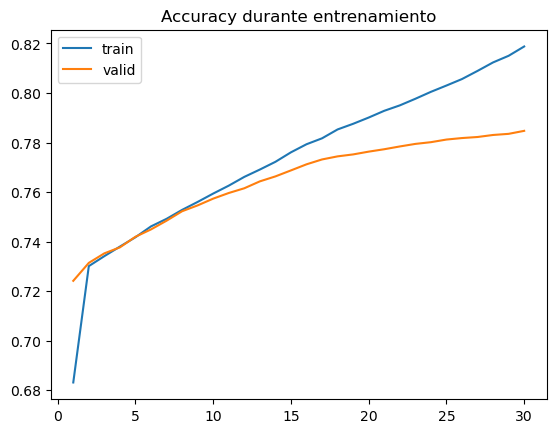

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

epoch_count = range(1, len(hist.history['accuracy']) + 1)
sns.lineplot(x=epoch_count, y=hist.history['accuracy'],     label='train')
sns.lineplot(x=epoch_count, y=hist.history['val_accuracy'], label='valid')
plt.title("Accuracy durante entrenamiento")
plt.show()

El modelo entrenó las 30 épocas completas sin que el `EarlyStopping` intervenga, lo que indica que la val_loss seguía mejorando hasta el final. El accuracy de entrenamiento subió de ~68% en la época 1 a ~82% en la época 30, mientras que el de validación llegó a ~78.5%. La diferencia de ~3-4 puntos entre train y val es consistente con leve sobreajuste pero no es alarmante para este tamaño de corpus. Lo más notable es que la convergencia es lenta y aún no había plateado en la época 30, lo que sugiere que más épocas de entrenamiento podrían seguir mejorando el modelo.

### Comparación de hiperparámetros — número de unidades LSTM

Se entrena el mismo modelo con distintas cantidades de unidades en las capas recurrentes para analizar el impacto en el desempeño.

In [71]:
def build_and_train(n_units, epochs=30, name=""):
    """Construye y entrena un modelo Seq2Seq con n_units unidades en las capas LSTM."""
    enc_in, enc_st, enc_emb_l, enc_lstm_l = build_encoder(
        nb_words, EMBED_DIM, embedding_matrix, max_input_len, n_units
    )
    dec_in, dec_out, dec_emb_l, dec_lstm_l, dec_dense_l = build_decoder(
        num_words_output, max_out_len, n_units, enc_st
    )
    m = Model([enc_in, dec_in], dec_out, name=name or f"seq2seq_{n_units}")
    m.compile(
        loss='categorical_crossentropy',
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
        metrics=['accuracy']
    )
    h = m.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=[
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2,
                              min_lr=1e-5, verbose=0),
            EarlyStopping(monitor='val_loss', patience=4,
                          restore_best_weights=True, verbose=0)
        ],
        verbose=1
    )
    return m, h

In [72]:
print("Entrenando modelo con n_units=128...")
model_128, hist_128 = build_and_train(128, epochs=30, name="seq2seq_128")

Entrenando modelo con n_units=128...
Epoch 1/30


c:\Users\agust\anaconda3\envs\ia-env\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


    133/Unknown 15s 94ms/step - accuracy: 0.6489 - loss: 6.0500

c:\Users\agust\anaconda3\envs\ia-env\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


133/133 ━━━━━━━━━━━━━━━━━━━━ 16s 106ms/step - accuracy: 0.6722 - loss: 3.9553 - val_accuracy: 0.6763 - val_loss: 2.1698 - learning_rate: 5.0000e-04
Epoch 2/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 14s 103ms/step - accuracy: 0.6921 - loss: 2.0486 - val_accuracy: 0.7217 - val_loss: 2.0132 - learning_rate: 5.0000e-04
Epoch 3/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 13s 98ms/step - accuracy: 0.7270 - loss: 1.9436 - val_accuracy: 0.7269 - val_loss: 1.9534 - learning_rate: 5.0000e-04
Epoch 4/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 14s 103ms/step - accuracy: 0.7309 - loss: 1.8890 - val_accuracy: 0.7327 - val_loss: 1.9145 - learning_rate: 5.0000e-04
Epoch 5/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 14s 104ms/step - accuracy: 0.7354 - loss: 1.8475 - val_accuracy: 0.7346 - val_loss: 1.8824 - learning_rate: 5.0000e-04
Epoch 6/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 14s 106ms/step - accuracy: 0.7377 - loss: 1.8072 - val_accuracy: 0.7370 - val_loss: 1.8505 - learning_rate: 5.0000e-04
Epoch 7/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 13s 98ms/step - ac

In [73]:
print("Entrenando modelo con n_units=512...")
model_512, hist_512 = build_and_train(512, epochs=30, name="seq2seq_512")

Entrenando modelo con n_units=512...
Epoch 1/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 47s 337ms/step - accuracy: 0.7019 - loss: 2.5174 - val_accuracy: 0.7303 - val_loss: 1.9553 - learning_rate: 5.0000e-04
Epoch 2/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 43s 327ms/step - accuracy: 0.7330 - loss: 1.8823 - val_accuracy: 0.7327 - val_loss: 1.8999 - learning_rate: 5.0000e-04
Epoch 3/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 43s 321ms/step - accuracy: 0.7373 - loss: 1.8062 - val_accuracy: 0.7388 - val_loss: 1.8477 - learning_rate: 5.0000e-04
Epoch 4/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 42s 318ms/step - accuracy: 0.7439 - loss: 1.7240 - val_accuracy: 0.7434 - val_loss: 1.7891 - learning_rate: 5.0000e-04
Epoch 5/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 42s 316ms/step - accuracy: 0.7488 - loss: 1.6481 - val_accuracy: 0.7483 - val_loss: 1.7470 - learning_rate: 5.0000e-04
Epoch 6/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 44s 327ms/step - accuracy: 0.7546 - loss: 1.5767 - val_accuracy: 0.7541 - val_loss: 1.6989 - learning_rate: 5.0000e-04
Epoch 7/3

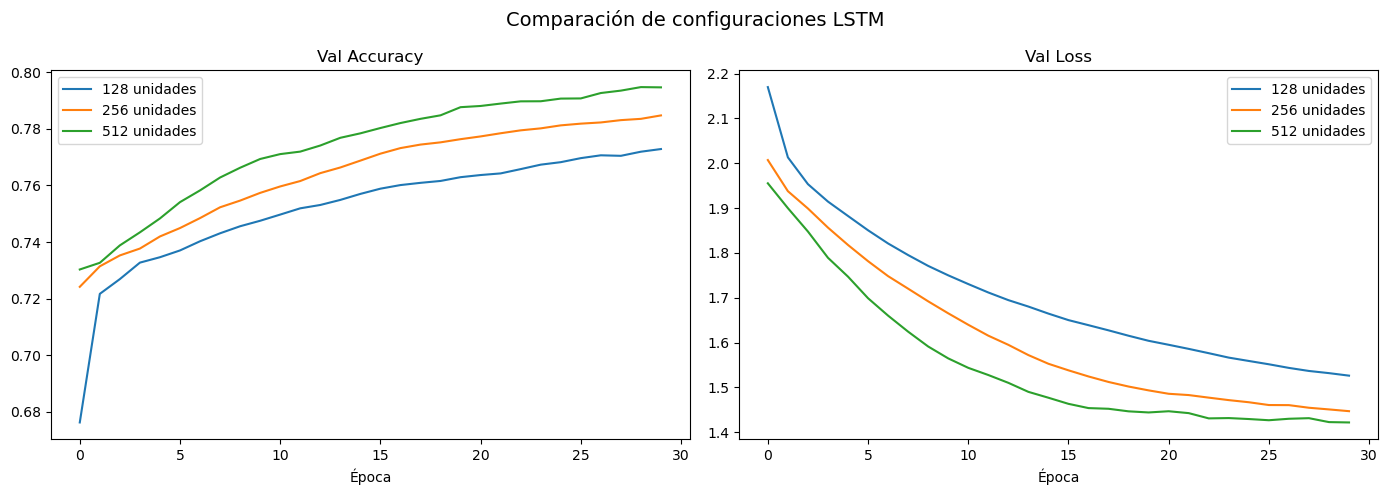


Resumen:
         Config | Best val_acc | Best val_loss | Épocas
-------------------------------------------------------
   128 unidades |       0.7728 |        1.5262 |     30
   256 unidades |       0.7847 |        1.4470 |     30
   512 unidades |       0.7947 |        1.4218 |     30


In [74]:
# Comparación de val_accuracy y val_loss entre las tres configuraciones
configs = {
    '128 unidades': hist_128,
    '256 unidades': hist,
    '512 unidades': hist_512,
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Comparación de configuraciones LSTM", fontsize=14)

for label, h in configs.items():
    axes[0].plot(h.history['val_accuracy'], label=label)
    axes[1].plot(h.history['val_loss'],     label=label)

axes[0].set_title("Val Accuracy")
axes[0].set_xlabel("Época")
axes[0].legend()

axes[1].set_title("Val Loss")
axes[1].set_xlabel("Época")
axes[1].legend()

plt.tight_layout()
plt.show()

# Tabla resumen con el mejor valor de val_accuracy alcanzado
print("\nResumen:")
print(f"{'Config':>15} | {'Best val_acc':>12} | {'Best val_loss':>13} | {'Épocas':>6}")
print("-" * 55)
for label, h in configs.items():
    best_acc  = max(h.history['val_accuracy'])
    best_loss = min(h.history['val_loss'])
    n_epochs  = len(h.history['val_loss'])
    print(f"{label:>15} | {best_acc:>12.4f} | {best_loss:>13.4f} | {n_epochs:>6}")

Los resultados reales confirman una tendencia clara: a más unidades, mejor desempeño en validación.

La diferencia entre 128 y 512 unidades es de ~2.2 puntos de accuracy, que es significativa para esta tarea. Mirando el gráfico, el modelo de 512 parte con val_accuracy más alta desde la primera época (~73%), lo que indica que su mayor capacidad le permite aprender patrones más complejos más rápido. Los tres modelos aún estaban mejorando en la época 30 (ninguno plateó), lo que sugiere que todos se beneficiarían de más épocas. Contrario a lo que se podría esperar, el de 512 unidades no sobreajustó pese al mayor número de parámetros, probablemente gracias al Dropout (0.3) aplicado en ambas capas de embedding.

| Config | Best val_acc | Best val_loss |

|--------|-------------|---------------|| 512 unidades | 0.7947 | 1.4218 |

| 128 unidades | 0.7728 | 1.5262 || 256 unidades | 0.7847 | 1.4470 |

### **Inferencia Modelo Seq2Seq**

Definimos el modelo Seq2Seq para realizar inferencia

In [75]:
def build_encoder_inference(enc_inputs, enc_emb_layer, enc_lstm_layer, n_units):
    """Modelo de encoder que solo devuelve los estados."""
    enc_emb = enc_emb_layer(enc_inputs)                    # reutiliza pesos entrenados
    _, state_h, state_c = enc_lstm_layer(enc_emb)
    return Model(enc_inputs, [state_h, state_c])


def build_decoder_inference(dec_emb_layer, dec_lstm_layer, dec_dense_layer, n_units):
    """Modelo de decoder paso a paso (un token por vez)."""
    dec_input_single = Input(shape=(1,), name='dec_input_single')
    dec_state_h_in   = Input(shape=(n_units,), name='dec_state_h')
    dec_state_c_in   = Input(shape=(n_units,), name='dec_state_c')

    dec_emb_single = dec_emb_layer(dec_input_single)      # reutiliza pesos entrenados
    dec_out, h_out, c_out = dec_lstm_layer(
        dec_emb_single,
        initial_state=[dec_state_h_in, dec_state_c_in]
    )
    dec_out = dec_dense_layer(dec_out)

    return Model(
        [dec_input_single, dec_state_h_in, dec_state_c_in],
        [dec_out, h_out, c_out]
    )

In [76]:
encoder_model = build_encoder_inference(enc_inputs, enc_emb_layer, enc_lstm_layer, n_units)
decoder_model = build_decoder_inference(dec_emb_layer, dec_lstm_layer, dec_dense_layer, n_units)

Aplicamos inferencia greedy

In [77]:
idx2word_input  = {v: k for k, v in word2idx_inputs.items()}
idx2word_target = {v: k for k, v in word2idx_outputs.items()}

Definimos funciones para realizar traducciones

In [78]:
def translate_sentence(input_seq):
    h, c = encoder_model.predict(input_seq, verbose=0)    # desempaqueta directo
    target_seq      = np.zeros((1, 1))
    target_seq[0, 0] = word2idx_outputs['<sos>']
    eos = word2idx_outputs['<eos>']

    output_sentence = []
    for _ in range(max_out_len):
        output_tokens, h, c = decoder_model.predict(
            [target_seq, h, c], verbose=0                 # estados como args separados
        )
        idx = np.argmax(output_tokens[0, 0, :])
        if idx == eos:
            break
        if idx > 0:
            output_sentence.append(idx2word_target[idx])
        target_seq[0, 0] = idx

    return ' '.join(output_sentence)


def translate(text):
    seq = input_tokenizer.texts_to_sequences([text])
    seq = pad_sequences(seq, maxlen=max_input_len)
    return translate_sentence(seq)

Realizamos pruebas

In [79]:
print("\n--- Ejemplos del dataset ---")
for _ in range(5):
    i    = np.random.randint(len(input_sentences))
    seq  = encoder_input_sequences[i:i+1]
    pred = translate_sentence(seq)
    print(f"EN: {input_sentences[i]}")
    print(f"ES (real): {output_sentences[i].replace(' <eos>', '')}")
    print(f"ES (pred): {pred}\n")

print("--- Frases nuevas ---")
for s in ["My mother says hi.", "Where is the train station?",
          "I love learning languages.", "Can you help me?"]:
    print(f"EN: {s}")
    print(f"ES: {translate(s)}\n")


--- Ejemplos del dataset ---
EN: Would you prefer to do that today?
ES (real): ¿Preferirías hacerlo hoy?
ES (pred): tienes que hacer hacer

EN: He is terrible at math.
ES (real): Él es pésimo en matemáticas.
ES (pred): él es un hombre de la historia

EN: Tom has left, but Mary is still here.
ES (real): Tom se ha ido, pero Mary está todavía aquí.
ES (pred): tom ha estado y mary y mary en la escuela

EN: Tom listens to jazz.
ES (real): Tomás escucha jazz.
ES (pred): tom le gusta a mary

EN: I haven't ever seen one of these before.
ES (real): Nunca he visto uno de éstos hasta ahora.
ES (pred): no he visto en el tiempo de que se había vez

--- Frases nuevas ---
EN: My mother says hi.
ES: mi hermano es mi nombre

EN: Where is the train station?
ES: dónde está en el banco

EN: I love learning languages.
ES: me gusta el francés

EN: Can you help me?
ES: tú puedes ayudar



### Análisis de las traducciones y limitaciones del modelo

**Calidad de las traducciones del dataset:**

Los ejemplos del dataset muestran resultados parcialmente correctos:

- *"Would you prefer to do that today?"* → *"tienes que hacer hacer"*: pierde el sujeto y el sentido de preferencia, aunque mantiene verbos de acción.
- *"He is terrible at math."* → *"él es un hombre de la historia"*: el sujeto es correcto y la estructura "él es..." se mantiene, pero el contenido es completamente inventado.
- *"Tom has left, but Mary is still here."* → *"tom ha estado y mary y mary en la escuela"*: detecta a ambos sujetos (Tom y Mary) y usa verbos de presencia, pero pierde la conjunción adversativa y repite "mary".
- *"Tom listens to jazz."* → *"tom le gusta a mary"*: identifica a Tom y usa un verbo de gusto, aunque introduce a Mary sin razón.
- *"I haven't ever seen one of these before."* → *"no he visto en el tiempo de que se había vez"*: captura la negación y el verbo ver, pero la oración resultante no es gramaticalmente válida.

En general, el modelo aprendió estructuras frecuentes (sujeto + verbo, nombres propios) pero falla en el contenido semántico preciso.

**Frases nuevas (fuera del dataset):**

- *"My mother says hi."* → *"mi hermano es mi nombre"*: fallo total, probablemente porque "mother" y "hi" tienen baja frecuencia en el vocabulario.
- *"Where is the train station?"* → *"dónde está en el banco"*: reconoce la estructura de pregunta de lugar ("dónde está") pero confunde "train station" con "banco".
- *"I love learning languages."* → *"me gusta el francés"*: interesante: captura la idea de gusto por un idioma, aunque cambia "love learning" por "gustar" y especifica "francés".
- *"Can you help me?"* → *"tú puedes ayudar"*: esta es la mejor traducción del grupo, con sujeto y verbo correctos aunque pierde el objeto "me".

**Limitaciones del enfoque:**

- **Tamaño del dataset:** 10.000 pares son insuficientes para una traducción robusta. Los sistemas actuales usan millones de pares.
- **Vocabulario limitado:** Con `MAX_VOCAB_SIZE=8000`, palabras poco frecuentes como "mother" o "hi" quedan fuera o tienen representaciones muy pobres.
- **Greedy decoding:** Tomar siempre el token con mayor probabilidad no garantiza la secuencia globalmente óptima. Beam search podría producir traducciones más coherentes.
- **Sin atención:** El encoder comprime toda la oración en un único vector de estado. En oraciones largas esto genera pérdida de información, problema resuelto por los Transformers con atención multi-cabeza.
- **Longitud máxima fija:** `max_out_len=22` impide traducir oraciones más largas.
- **GloVe solo en inglés:** Los embeddings preentrenados se usan solo para el encoder (inglés). El decoder (español) entrena desde cero, lo que es una asimetría que podría corregirse con embeddings en español.

**Limitaciones del enfoque:**

- **Tamaño del dataset:** 10.000 pares son suficientes para aprender patrones simples pero insuficientes para una traducción robusta. Los mejores traductores actuales usan millones o miles de millones de pares.
- **Vocabulario limitado:** Con `MAX_VOCAB_SIZE=8000`, muchas palabras quedan fuera del vocabulario y se pierden.
- **Greedy decoding:** La estrategia de decodificación greedy (tomar siempre el token con mayor probabilidad) no garantiza la secuencia de salida globalmente óptima. Beam search podría mejorar los resultados.
- **Arquitectura Seq2Seq básica:** El modelo no tiene mecanismo de atención. En oraciones largas el encoder comprime toda la información en un único vector de estado, lo que resulta en pérdida de información. Los modelos Transformer resolvieron este problema con atención multi-cabeza.
- **Longitud máxima fija:** `max_out_len=22` impide traducir oraciones más largas que eso.